# Qubit readout: I–Q visualization

Three-panel figure: (a) Q vs time for states 0 and 1, (b) I–Q scatter, (c) Q histograms for state discrimination.

Data from `./data/` (same .npy files as global search).

In [36]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from utils.tf_data_preprocessing import load_and_preprocess_qubit

# Expects 0528_X_train_0_770.npy, 0528_y_train_0_770.npy, 0528_X_test_0_770.npy, 0528_y_test_0_770.npy in DATA_DIR
DATA_DIR = "./data"
START_LOCATION = 0   # Try 50, 100, etc. if data has more than 770 points per sample (full readout)
WINDOW_SIZE = 770   # Full readout window
SUBSET = 10000

x_train, y_train, x_test, y_test = load_and_preprocess_qubit(
    data_dir=DATA_DIR,
    start_location=START_LOCATION,
    window_size=WINDOW_SIZE,
    subset_size=SUBSET,
    normalize=False,
    flatten=True,
    one_hot=False,
)

X = np.vstack([x_train, x_test])
y = np.concatenate([y_train, y_test])
# Cap total samples used for plots (loader only subsets train; test is still full)
if SUBSET is not None:
    X = X[:SUBSET]
    y = y[:SUBSET]

I_all = X[:, 0::2]
Q_all = X[:, 1::2]
mask0 = (y == 0)
mask1 = (y == 1)
I0, Q0 = I_all[mask0], Q_all[mask0]
I1, Q1 = I_all[mask1], Q_all[mask1]

n_time = I_all.shape[1]
time_cycles = np.arange(n_time)
print("I/Q shapes:", I0.shape, Q0.shape, I1.shape, Q1.shape)
print("Time points:", n_time)
print("Class counts: state 0 =", mask0.sum(), ", state 1 =", mask1.sum(), "(imbalance → more orange if state 1 is larger)")

Qubit data loaded and preprocessed:
  data_dir: /home/users/jdweitz/qubit_snac-pack/nac-opt/qubit/data
  x_train shape: (10000, 1540), x_test shape: (100000, 1540)
  y_train shape: (10000,), y_test shape: (100000,)
I/Q shapes: (5000, 770) (5000, 770) (5000, 770) (5000, 770)
Time points: 770
Class counts: state 0 = 5000 , state 1 = 5000 (imbalance → more orange if state 1 is larger)


## (a) Time series: Q vs ADC clock cycle

Mean Q(t) for state 0 and state 1 (with shaded spread).

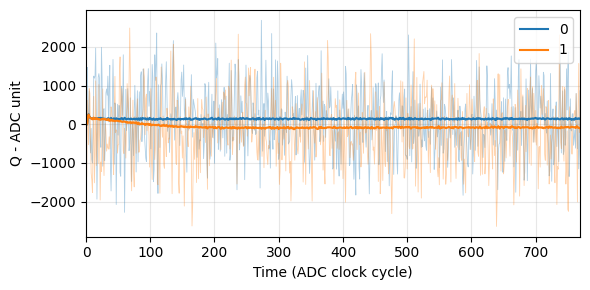

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

# Plot a sample of raw Q(t) traces (noisy) plus mean line (like reference)
n_show = min(1, Q0.shape[0], Q1.shape[0])  # sample of traces + mean line (like reference)
rng = np.random.default_rng(42)
idx0 = rng.choice(Q0.shape[0], size=n_show, replace=False)
idx1 = rng.choice(Q1.shape[0], size=n_show, replace=False)
for i in idx0:
    ax.plot(time_cycles, Q0[i], color='C0', alpha=0.35, lw=0.6)
for i in idx1:
    ax.plot(time_cycles, Q1[i], color='C1', alpha=0.35, lw=0.6)
q0_mean = Q0.mean(axis=0)
q1_mean = Q1.mean(axis=0)
ax.plot(time_cycles, q0_mean, color='C0', label='0', lw=1.5)
ax.plot(time_cycles, q1_mean, color='C1', label='1', lw=1.5)

ax.set_xlabel('Time (ADC clock cycle)')
ax.set_ylabel('Q - ADC unit')
ax.set_xlim(0, n_time - 1)
ax.legend(loc='upper right') # set the legend to the top right of the plot
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('single_avg.png', dpi=300)  # save before show() so file isn't blank
plt.savefig('single_avg.pdf', dpi=300)
plt.show()

## (b) I–Q scatter

Mean I and mean Q per sample (integrated over the readout window) for states 0 and 1.

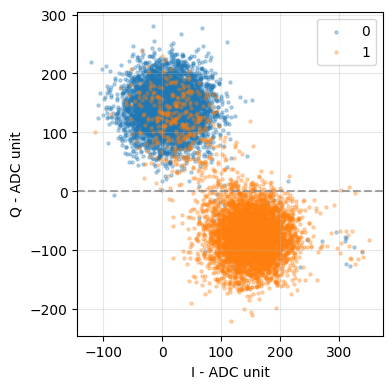

In [43]:
I0_mean = I0.mean(axis=1)
Q0_mean = Q0.mean(axis=1)
I1_mean = I1.mean(axis=1)
Q1_mean = Q1.mean(axis=1)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(I0_mean, Q0_mean, alpha=0.3, s=5, color='C0', label='0')
ax.scatter(I1_mean, Q1_mean, alpha=0.3, s=5, color='C1', label='1')
ax.axhline(0, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('I - ADC unit')
ax.set_ylabel('Q - ADC unit')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_I.png', dpi=300)  # save before show() so file isn't blank
plt.savefig('avg_I.pdf', dpi=300)
plt.show()

## (c) Q histograms

Distribution of mean Q per sample for each state (Q=0 as typical separator).

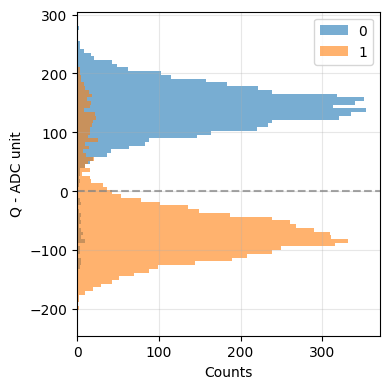

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Standard horizontal histograms (both with positive counts to the right, like reference)
bins = np.linspace(min(Q0_mean.min(), Q1_mean.min()), max(Q0_mean.max(), Q1_mean.max()), 80)
ax.hist(Q0_mean, bins=bins, alpha=0.6, color='C0', label='0', orientation='horizontal', density=False)
ax.hist(Q1_mean, bins=bins, alpha=0.6, color='C1', label='1', orientation='horizontal', density=False)
ax.axhline(0, color='gray', ls='--', alpha=0.7)
ax.set_xlabel('Counts')
ax.set_ylabel('Q - ADC unit')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_counts.png', dpi=300)  # save before show() so file isn't blank
plt.savefig('avg_counts.pdf', dpi=300)
plt.show()

## Single figure: all three panels

Layout: (a) top full width, (b) bottom left, (c) bottom right.

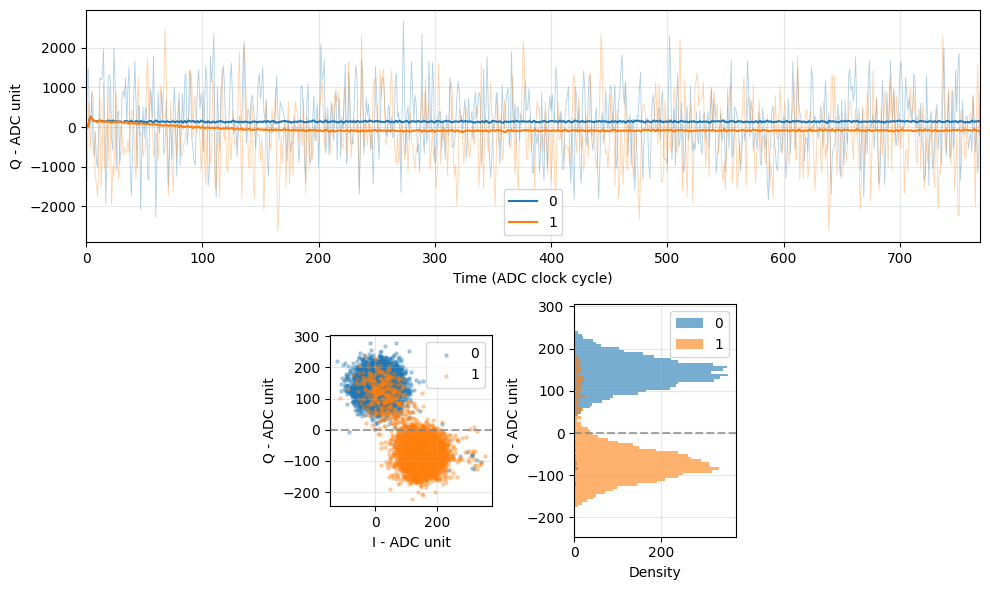

In [30]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(10, 6))
gs = GridSpec(2, 4, figure=fig)
ax_a = fig.add_subplot(gs[0, :])
n_show = min(1, Q0.shape[0], Q1.shape[0])  # fewer traces to reduce visual noise
rng = np.random.default_rng(42)
idx0 = rng.choice(Q0.shape[0], size=n_show, replace=False)
idx1 = rng.choice(Q1.shape[0], size=n_show, replace=False)
for i in idx0:
    ax_a.plot(time_cycles, Q0[i], color='C0', alpha=0.35, lw=0.6)
for i in idx1:
    ax_a.plot(time_cycles, Q1[i], color='C1', alpha=0.35, lw=0.6)
ax_a.plot(time_cycles, Q0.mean(axis=0), color='C0', label='0', lw=1.5)
ax_a.plot(time_cycles, Q1.mean(axis=0), color='C1', label='1', lw=1.5)
ax_a.set_xlabel('Time (ADC clock cycle)')
ax_a.set_ylabel('Q - ADC unit')
ax_a.set_xlim(0, n_time - 1)
ax_a.legend()
ax_a.grid(True, alpha=0.3)
ax_b = fig.add_subplot(gs[1, 1])
ax_b.scatter(I0_mean, Q0_mean, alpha=0.3, s=5, color='C0', label='0')
ax_b.scatter(I1_mean, Q1_mean, alpha=0.3, s=5, color='C1', label='1')
ax_b.axhline(0, color='gray', ls='--', alpha=0.7)
ax_b.set_xlabel('I - ADC unit')
ax_b.set_ylabel('Q - ADC unit')
ax_b.legend()
ax_b.set_aspect('equal')
ax_b.grid(True, alpha=0.3)
ax_c = fig.add_subplot(gs[1, 2])
ax_c.hist(Q0_mean, bins=bins, alpha=0.6, color='C0', label='0', orientation='horizontal', density=False)
ax_c.hist(Q1_mean, bins=bins, alpha=0.6, color='C1', label='1', orientation='horizontal', density=False)
ax_c.axhline(0, color='gray', ls='--', alpha=0.7)
ax_c.set_xlabel('Density')
ax_c.set_ylabel('Q - ADC unit')
ax_c.legend()
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('qubit_iq_visualization.png', dpi=150)  # save before show() so file isn't blank
plt.show()

## Multiple samples (loop)

Run the same 3-panel I-Q visualization for several data configs (e.g. different windows or files). Edit `SAMPLES` to add more.

Qubit data loaded and preprocessed:
  data_dir: /home/users/jdweitz/qubit_snac-pack/nac-opt/qubit/data
  x_train shape: (900000, 1540), x_test shape: (100000, 1540)
  y_train shape: (900000,), y_test shape: (100000,)


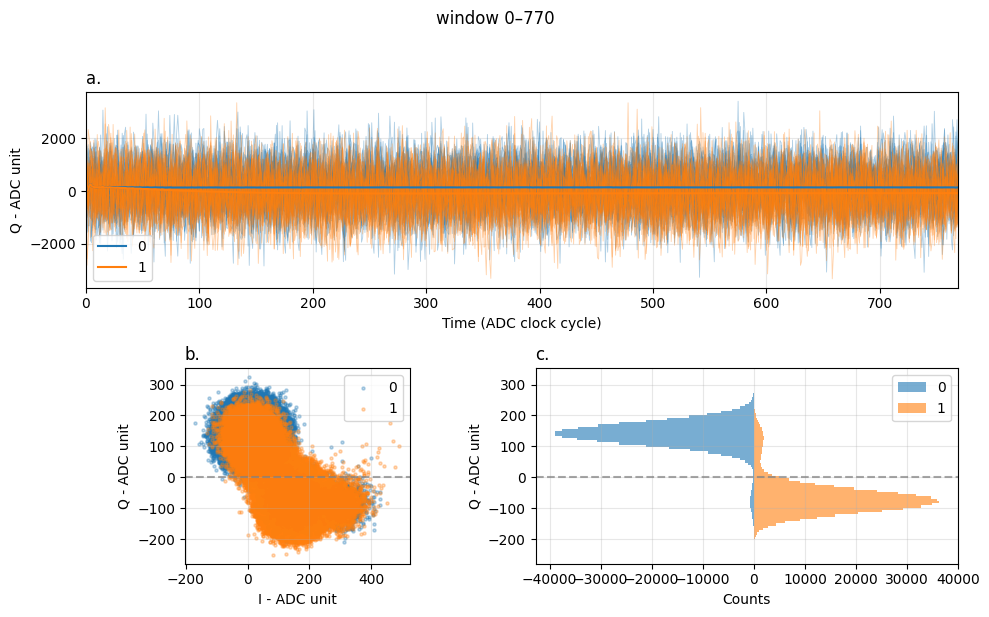

Qubit data loaded and preprocessed:
  data_dir: /home/users/jdweitz/qubit_snac-pack/nac-opt/qubit/data
  x_train shape: (900000, 800), x_test shape: (100000, 800)
  y_train shape: (900000,), y_test shape: (100000,)


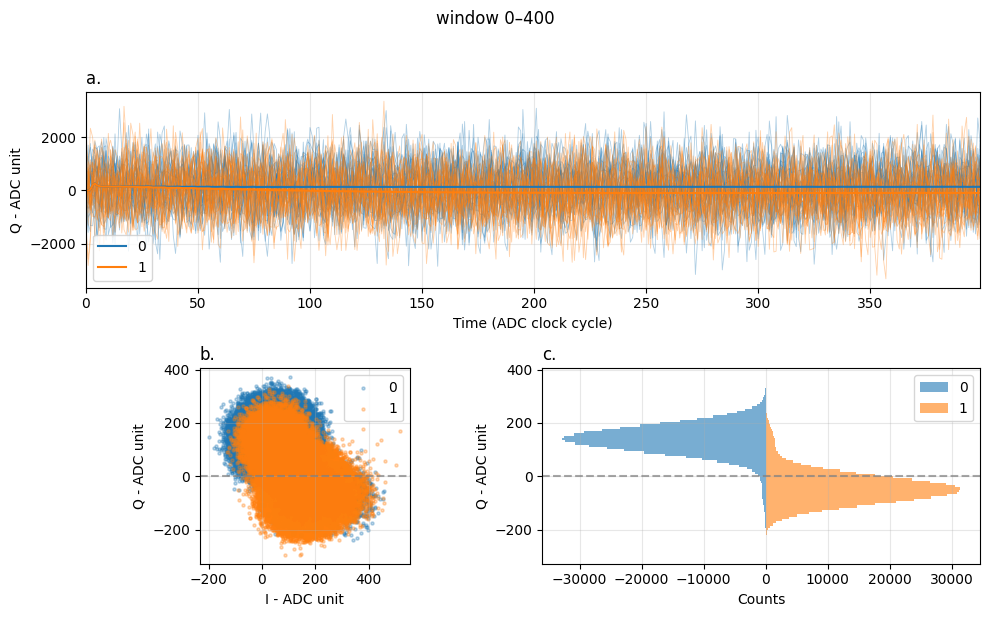

In [ ]:
def plot_iq_three_panel(x_train, y_train, x_test, y_test, title=None, n_show=25, seed=42, save_path=None):
    """Build I/Q arrays from train/test and draw the 3-panel (a) time series, (b) I-Q scatter, (c) Q histograms."""
    X = np.vstack([x_train, x_test])
    y = np.concatenate([y_train, y_test])
    if y.ndim > 1:
        y = np.argmax(y, axis=1)
    I_all = X[:, 0::2]
    Q_all = X[:, 1::2]
    mask0, mask1 = y == 0, y == 1
    I0, Q0 = I_all[mask0], Q_all[mask0]
    I1, Q1 = I_all[mask1], Q_all[mask1]
    I0_mean = I0.mean(axis=1)
    Q0_mean = Q0.mean(axis=1)
    I1_mean = I1.mean(axis=1)
    Q1_mean = Q1.mean(axis=1)
    n_time = Q_all.shape[1]
    time_cycles = np.arange(n_time)
    bins = np.linspace(min(Q0_mean.min(), Q1_mean.min()), max(Q0_mean.max(), Q1_mean.max()), 80)

    from matplotlib.gridspec import GridSpec
    fig = plt.figure(figsize=(10, 6))
    if title:
        fig.suptitle(title, y=1.02)
    gs = GridSpec(2, 4, figure=fig)
    ax_a = fig.add_subplot(gs[0, :])
    rng = np.random.default_rng(seed)
    n_show = min(n_show, Q0.shape[0], Q1.shape[0])
    idx0 = rng.choice(Q0.shape[0], size=n_show, replace=False)
    idx1 = rng.choice(Q1.shape[0], size=n_show, replace=False)
    for i in idx0:
        ax_a.plot(time_cycles, Q0[i], color='C0', alpha=0.35, lw=0.6)
    for i in idx1:
        ax_a.plot(time_cycles, Q1[i], color='C1', alpha=0.35, lw=0.6)
    ax_a.plot(time_cycles, Q0.mean(axis=0), color='C0', label='0', lw=1.5)
    ax_a.plot(time_cycles, Q1.mean(axis=0), color='C1', label='1', lw=1.5)
    ax_a.set_xlabel('Time (ADC clock cycle)')
    ax_a.set_ylabel('Q - ADC unit')
    ax_a.set_xlim(0, n_time - 1)
    ax_a.legend()
    ax_a.grid(True, alpha=0.3)
    ax_b = fig.add_subplot(gs[1, 1])
    ax_b.scatter(I0_mean, Q0_mean, alpha=0.3, s=5, color='C0', label='0')
    ax_b.scatter(I1_mean, Q1_mean, alpha=0.3, s=5, color='C1', label='1')
    ax_b.axhline(0, color='gray', ls='--', alpha=0.7)
    ax_b.set_xlabel('I - ADC unit')
    ax_b.set_ylabel('Q - ADC unit')
    ax_b.legend()
    ax_b.set_aspect('equal')
    ax_b.grid(True, alpha=0.3)
    ax_c = fig.add_subplot(gs[1, 2])
ax_c.hist(Q0_mean, bins=bins, alpha=0.6, color='C0', label='0', orientation='horizontal', density=True)
ax_c.hist(Q1_mean, bins=bins, alpha=0.6, color='C1', label='1', orientation='horizontal', density=True)
ax_c.axhline(0, color='gray', ls='--', alpha=0.7)
    ax_c.set_xlabel('Density')
    ax_c.set_ylabel('Q - ADC unit')
    ax_c.legend()
    ax_c.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)  # save before show() so file isn't blank
    plt.show()


# Fixed full window; loop over start indices (different "data point" in the long trace)
WINDOW_SIZE = 770
START_INDICES = [0, 100, 200]  # try other starts if data has more than 770 points per sample

for start_loc in START_INDICES:
    xt, yt, xv, yv = load_and_preprocess_qubit(
        data_dir=DATA_DIR,
        one_hot=False,
        start_location=start_loc,
        window_size=WINDOW_SIZE,
    )
    plot_iq_three_panel(xt, yt, xv, yv, title=f"start {start_loc}, window {WINDOW_SIZE}")